## **Understanding the Dataset**

In [ ]:
#STEP 1: Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/dataset'


Mounted at /content/drive


In [ ]:
#STEP 2: Read _classes.csv
import pandas as pd

train_csv_path = dataset_path + '/train/_classes.csv'
df = pd.read_csv(train_csv_path)
df.head()


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...,0,0,0,1
1,Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...,0,0,1,0
2,Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...,1,0,0,0
3,Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...,1,0,0,0
4,Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...,0,1,0,0


In [ ]:
#Review the Number of Categories and Sample Images
print("Tumor Categories:", list(df.columns[1:]))
print("Total Images:", len(df))


Tumor Categories: [' Glioma', ' Meningioma', ' No Tumor', ' Pituitary']
Total Images: 1695


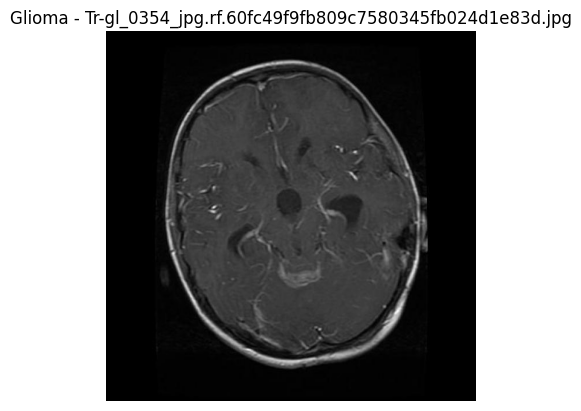

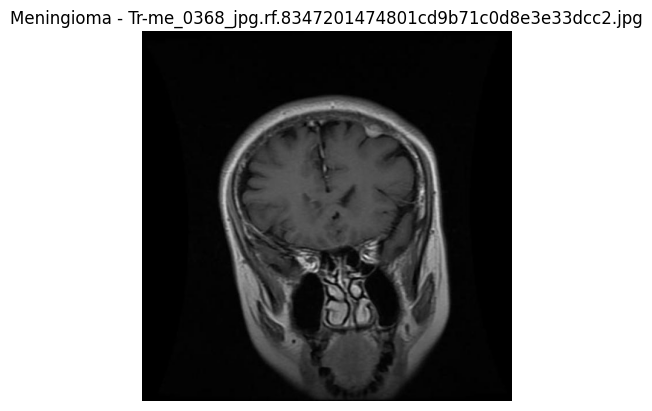

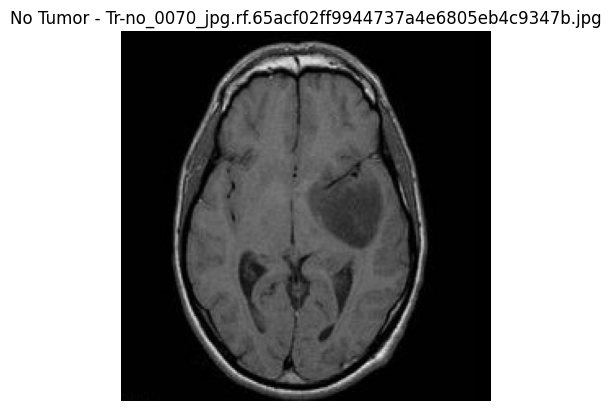

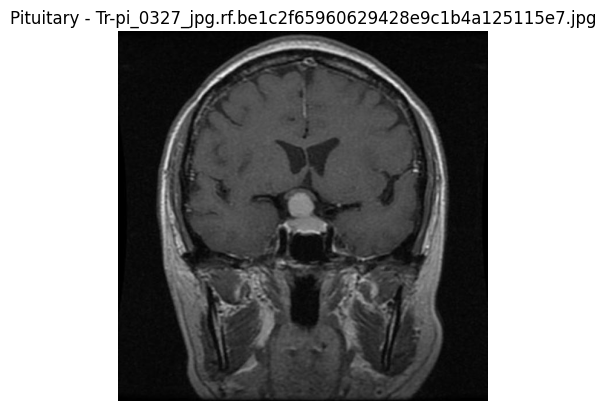

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

image_folder = dataset_path + '/train'  # Change this to /test or /validate as needed

filename_col = 'filename'
label_cols = [' Glioma', ' Meningioma', ' No Tumor', ' Pituitary']

for category in label_cols:
    # Pick one random image from this category
    sample_row = df[df[category] == 1].sample(1).iloc[0]
    image_name = sample_row[filename_col]


    # We need to remove the leading space from the category name before using it for the folder name.
    category_folder = category.strip().lower().replace(" ", "_")  # e.g., ' Glioma' → glioma
    img_path = os.path.join(image_folder, category_folder, image_name)

    # Debug check
    if not os.path.exists(img_path):
        print(f" File not found: {img_path}")
        continue

    image = cv2.imread(img_path)
    if image is None:
        print(f" Could not load image: {img_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(f"{category.strip()} - {image_name}") # Remove leading space for the title
    plt.axis('off')
    plt.show()

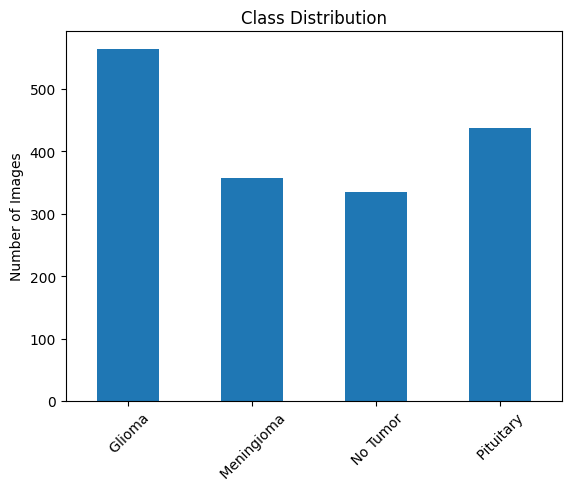

In [ ]:
# Check for Class Imbalance
category_counts = df.iloc[:, 1:].sum()
category_counts.plot(kind='bar', title='Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Check Image Resolution Consistency
from collections import Counter

img_sizes = []

for fname in df['filename']:
    for category in df.columns[1:]:
        # Only look into the first matching label to avoid duplicates
        if df.loc[df['filename'] == fname, category].values[0] == 1:
            img_path = os.path.join(image_folder, category, fname)
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    img_sizes.append(img.shape[:2])  # (height, width)
            break

size_counts = Counter(img_sizes)
print("Image size distribution (Height x Width):")
for size, count in size_counts.items():
    print(f"{size}: {count} images")


Image size distribution (Height x Width):


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
dataset_path = '/content/drive/MyDrive/dataset'
train_dir = dataset_path + '/train'
validation_dir = dataset_path + '/valid'
test_dir = dataset_path + '/test'

# Set target image size
target_size = (224, 224)
batch_size = 32

# Create ImageDataGenerators for each set
# Rescale pixel values to [0, 1]
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images and labels using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical') # Use categorical for one-hot encoded labels

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False) # No shuffling for validation

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False) # No shuffling for testing

# The generators will provide the data in batches.
# We can get the class labels mapping from the generators
print("Class labels mapping:", train_generator.class_indices)


# The variables train_generator, validation_generator, and test_generator
# represent the loaded and preprocessed data streams.
train_data = train_generator
validation_data = validation_generator
test_data = test_generator

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
Class labels mapping: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


## Data augmentation

### Subtask:
Implement data augmentation techniques to increase the size and diversity of the training dataset.


**Reasoning**:
Implement data augmentation for the training data using ImageDataGenerator and create generators for training, validation, and test sets with appropriate parameters.



In [ ]:
# Create an instance of ImageDataGenerator for training data augmentation.
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create instances of ImageDataGenerator for validation and test data (only rescaling).
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Use flow_from_directory to create augmented data generators.
train_data = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Augmented training data generator created.")
print("Validation data generator created.")
print("Test data generator created.")

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
Augmented training data generator created.
Validation data generator created.
Test data generator created.


## Check image resolution consistency

### Subtask:
Explain the error in the selected code, fix it if possible, and incorporate the changes into the existing code. If fixing is not possible, diagnose the error.


**Reasoning**:
Analyze the provided code and its output to identify the error in determining image sizes and then fix the code to correctly read image sizes from the correct directory structure.



In [ ]:
# Check Image Resolution Consistency
from collections import Counter
import os
import cv2 # Import cv2 if it wasn't imported before

img_sizes = []

# The issue in the previous code was that it was looking for images directly in the category folder,
# e.g., '/content/drive/MyDrive/dataset/train/ Glioma/Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...'.
# However, based on the successful image loading in the previous steps,
# the correct structure is '/content/drive/MyDrive/dataset/train/glioma/Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...'.
# The category folder names are lowercase and do not have leading spaces.

# Need to iterate through each row of the dataframe to get filename and category.
for index, row in df.iterrows():
    fname = row['filename']
    # Find the correct category folder name for this image
    category_folder = None
    for category in df.columns[1:]:
        if row[category] == 1:
            # Clean up the category name to match the directory structure
            category_folder = category.strip().lower().replace(" ", "_")
            break # Assuming each image belongs to only one category

    if category_folder:
        # Construct the correct image path
        img_path = os.path.join(image_folder, category_folder, fname)

        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                img_sizes.append(img.shape[:2])  # (height, width)
            # else:
                # print(f"Could not read image: {img_path}") # Optional: for debugging unreadable images
        # else:
            # print(f"File not found: {img_path}") # Optional: for debugging missing files
    # else:
        # print(f"Could not determine category for file: {fname}") # Optional: for debugging files without a category

size_counts = Counter(img_sizes)
print("Image size distribution (Height x Width):")
for size, count in size_counts.items():
    print(f"{size}: {count} images")


Image size distribution (Height x Width):
(640, 640): 1695 images


## Model building (custom cnn)

### Subtask:
Design and build a custom Convolutional Neural Network model.


**Reasoning**:
Design and build a custom Convolutional Neural Network model using the specified Keras layers and compile it.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Instantiate a Sequential model.
model = Sequential()

# 2. Add convolutional layers (Conv2D) and pooling layers (MaxPooling2D).
# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(target_size[0], target_size[1], 3)))
model.add(MaxPooling2D((2, 2)))

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Fourth convolutional layer (optional, adding more complexity)
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))


# 3. Flatten the output of the convolutional and pooling layers.
model.add(Flatten())

# 4. Add dense layers (Dense).
# First dense layer
model.add(Dense(512, activation='relu'))

# 5. Add a final dense layer with the number of units equal to the number of classes and an 'softmax' activation function.
# Determine the number of classes from the training generator
num_classes = train_data.num_classes
model.add(Dense(num_classes, activation='softmax'))

# 6. Compile the model.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 7. Print a summary of the model architecture.
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,680,580 (36.93 MB)

 Trainable params: 9,680,580 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

## Check image resolution consistency

### Subtask:
Explain the error in the selected code, fix it if possible, and incorporate the changes into the existing code. If fixing is not possible, diagnose the error.


## Model building (transfer learning)

### Subtask:
Load pretrained models and adapt them for the specific task of tumor classification.


**Reasoning**:
Import necessary Keras applications and build each model as specified in the instructions.



In [ ]:
from tensorflow.keras.applications import ResNet50, MobileNetV2, InceptionV3, EfficientNetB0
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import layers

# Get the number of classes from the training generator
num_classes = train_data.num_classes
input_shape = (target_size[0], target_size[1], 3)

# 1. ResNet50 Model
print("Building ResNet50 Model...")
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
x = Flatten()(base_resnet.output)
x = Dense(512, activation='relu')(x)
resnet_model = Model(inputs=base_resnet.input, outputs=Dense(num_classes, activation='softmax')(x))

resnet_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
print("ResNet50 Model Summary:")
resnet_model.summary()

# 2. MobileNetV2 Model
print("\nBuilding MobileNetV2 Model...")
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
x = Flatten()(base_mobilenet.output)
x = Dense(512, activation='relu')(x)
mobilenet_model = Model(inputs=base_mobilenet.input, outputs=Dense(num_classes, activation='softmax')(x))

mobilenet_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
print("MobileNetV2 Model Summary:")
mobilenet_model.summary()

# 3. InceptionV3 Model
print("\nBuilding InceptionV3 Model...")
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
x = Flatten()(base_inception.output)
x = Dense(512, activation='relu')(x)
inception_model = Model(inputs=base_inception.input, outputs=Dense(num_classes, activation='softmax')(x))

inception_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
print("InceptionV3 Model Summary:")
inception_model.summary()

# 4. EfficientNetB0 Model
print("\nBuilding EfficientNetB0 Model...")
base_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
x = Flatten()(base_efficientnet.output)
x = Dense(512, activation='relu')(x)
efficientnet_model = Model(inputs=base_efficientnet.input, outputs=Dense(num_classes, activation='softmax')(x))

efficientnet_model.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])
print("EfficientNetB0 Model Summary:")
efficientnet_model.summary()

Building ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 Model Summary:


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 74,970,500 (285.99 MB)

 Trainable params: 74,917,380 (285.79 MB)

...

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 36,164,775 (137.96 MB)

 Trainable params: 36,122,752 (137.80 MB)

 Non-trainable params: 42,023 (164.16 KB)

## Model training

### Subtask:
Train both the custom CNN and transfer learning models, using callbacks for monitoring and saving the best models.


**Reasoning**:
Define ModelCheckpoint and EarlyStopping callbacks for each model and then train each model using the respective generators and callbacks.



In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

# Define callback directory
callback_dir = '/content/drive/MyDrive/model_callbacks'
os.makedirs(callback_dir, exist_ok=True)

# --- Custom CNN Callbacks ---
custom_cnn_checkpoint = ModelCheckpoint(
    os.path.join(callback_dir, 'best_custom_cnn_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

custom_cnn_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10, # Number of epochs with no improvement after which training will be stopped.
    mode='max',
    verbose=1,
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

custom_cnn_callbacks = [custom_cnn_checkpoint, custom_cnn_early_stopping]

# --- ResNet50 Callbacks ---
resnet_checkpoint = ModelCheckpoint(
    os.path.join(callback_dir, 'best_resnet50_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

resnet_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

resnet_callbacks = [resnet_checkpoint, resnet_early_stopping]

# --- MobileNetV2 Callbacks ---
mobilenet_checkpoint = ModelCheckpoint(
    os.path.join(callback_dir, 'best_mobilenetv2_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

mobilenet_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

mobilenet_callbacks = [mobilenet_checkpoint, mobilenet_early_stopping]

# --- InceptionV3 Callbacks ---
inception_checkpoint = ModelCheckpoint(
    os.path.join(callback_dir, 'best_inceptionv3_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

inception_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

inception_callbacks = [inception_checkpoint, inception_early_stopping]

# --- EfficientNetB0 Callbacks ---
efficientnet_checkpoint = ModelCheckpoint(
    os.path.join(callback_dir, 'best_efficientnetb0_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

efficientnet_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

efficientnet_callbacks = [efficientnet_checkpoint, efficientnet_early_stopping]

# --- Train Models ---
epochs = 50 # Define a reasonable number of epochs

print("\nTraining Custom CNN Model...")
history_custom_cnn = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    epochs=epochs,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batch_size,
    callbacks=custom_cnn_callbacks
)

print("\nTraining ResNet50 Model...")
history_resnet = resnet_model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    epochs=epochs,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batch_size,
    callbacks=resnet_callbacks
)

print("\nTraining MobileNetV2 Model...")
history_mobilenet = mobilenet_model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    epochs=epochs,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batch_size,
    callbacks=mobilenet_callbacks
)

print("\nTraining InceptionV3 Model...")
history_inception = inception_model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    epochs=epochs,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batch_size,
    callbacks=inception_callbacks
)

print("\nTraining EfficientNetB0 Model...")
history_efficientnet = efficientnet_model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    epochs=epochs,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batch_size,
    callbacks=efficientnet_callbacks
)

print("\nModel training completed.")


Training Custom CNN Model...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.4127 - loss: 1.3160
Epoch 1: val_accuracy improved from -inf to 0.53333, saving model to /content/drive/MyDrive/model_callbacks/best_custom_cnn_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 459s 9s/step - accuracy: 0.4138 - loss: 1.3139 - val_accuracy: 0.5333 - val_loss: 1.0376
Epoch 2/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5312 - loss: 1.0856

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.53333
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 408ms/step - accuracy: 0.5312 - loss: 1.0856 - val_accuracy: 0.5250 - val_loss: 1.0286
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5779 - loss: 1.0372
Epoch 3: val_accuracy improved from 0.53333 to 0.68958, saving model to /content/drive/MyDrive/model_callbacks/best_custom_cnn_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 58s 657ms/step - accuracy: 0.5781 - loss: 1.0365 - val_accuracy: 0.6896 - val_loss: 0.8090
Epoch 4/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5312 - loss: 1.2650
Epoch 4: val_accuracy did not improve from 0.68958
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5312 - loss: 1.2650 - val_accuracy: 0.6625 - val_loss: 0.8173
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6237 - loss: 0.9068
Epoch 5: val_accuracy did not improve from 0.68958
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 717ms/step - accuracy: 0.6242 - loss: 0.9063 - val_accuracy: 0.6792

## Model Evaluation

### Subtask:
Evaluate models using metrics like accuracy, precision, recall, F1-score, and confusion matrix. Visualize model performance trends using training history plots for accuracy and loss.

Evaluating Custom CNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 150s 21s/step

Classification Report for Custom CNN:

              precision    recall  f1-score   support

      glioma       0.87      0.89      0.88        80
  meningioma       0.75      0.57      0.65        63
    no_tumor       0.75      0.88      0.81        49
   pituitary       0.85      0.93      0.88        54

    accuracy                           0.81       246
   macro avg       0.80      0.82      0.81       246
weighted avg       0.81      0.81      0.81       246


Confusion Matrix for Custom CNN:

[[71  5  2  2]
 [ 9 36 12  6]
 [ 0  5 43  1]
 [ 2  2  0 50]]


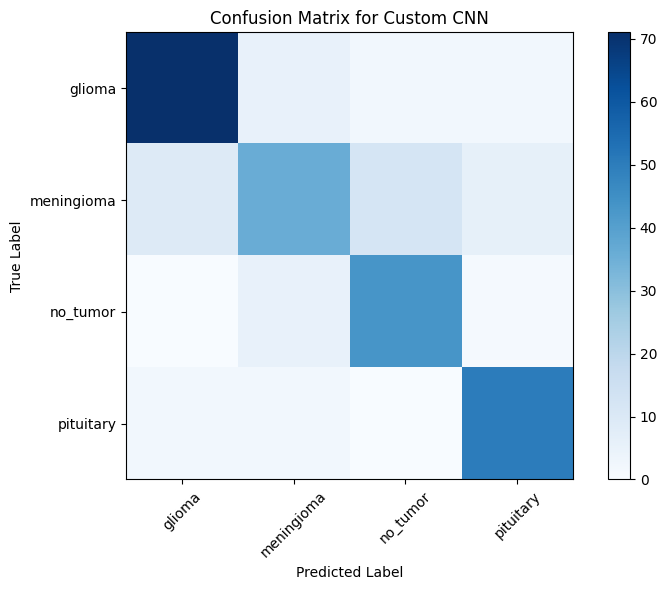

Evaluating ResNet50...
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

Classification Report for ResNet50:

              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246


Confusion Matrix for ResNet50:

[[80  0  0  0]
 [63  0  0  0]
 [49  0  0  0]
 [54  0  0  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


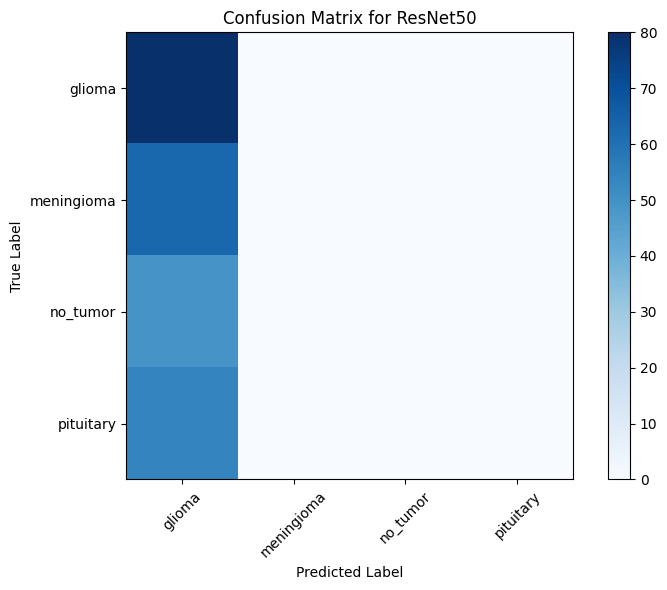

Evaluating MobileNetV2...


8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

Classification Report for MobileNetV2:

              precision    recall  f1-score   support

      glioma       0.80      0.91      0.85        80
  meningioma       0.49      0.78      0.60        63
    no_tumor       0.78      0.88      0.83        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.67       246
   macro avg       0.52      0.64      0.57       246
weighted avg       0.54      0.67      0.60       246


Confusion Matrix for MobileNetV2:

[[73  7  0  0]
 [13 49  1  0]
 [ 1  5 43  0]
 [ 4 39 11  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


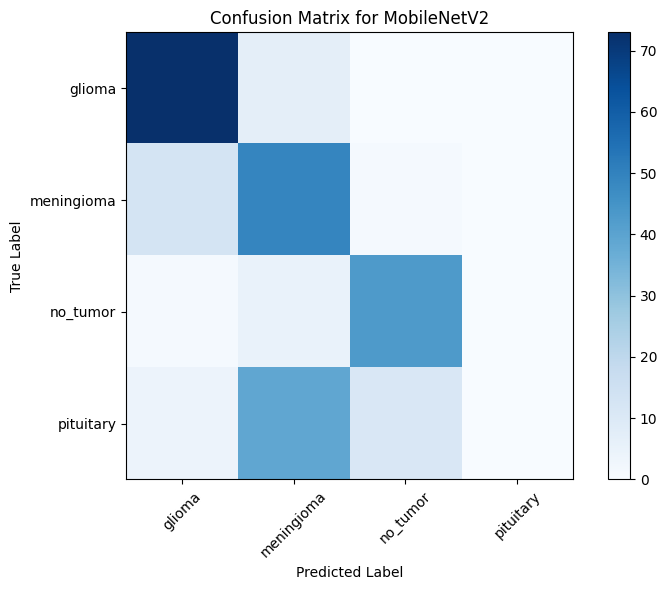

Evaluating InceptionV3...


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step

Classification Report for InceptionV3:

              precision    recall  f1-score   support

      glioma       0.95      0.96      0.96        80
  meningioma       0.89      0.92      0.91        63
    no_tumor       1.00      0.82      0.90        49
   pituitary       0.90      1.00      0.95        54

    accuracy                           0.93       246
   macro avg       0.94      0.92      0.93       246
weighted avg       0.93      0.93      0.93       246


Confusion Matrix for InceptionV3:

[[77  1  0  2]
 [ 2 58  0  3]
 [ 2  6 40  1]
 [ 0  0  0 54]]


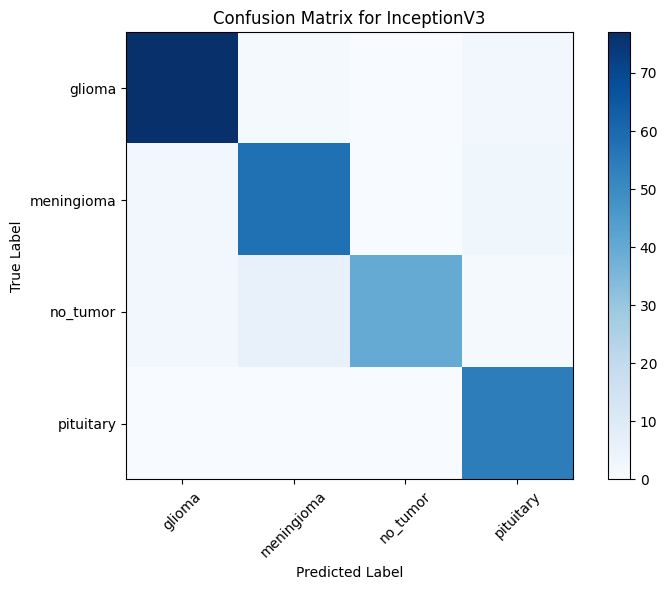

Evaluating EfficientNetB0...
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step

Classification Report for EfficientNetB0:

              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246


Confusion Matrix for EfficientNetB0:

[[80  0  0  0]
 [63  0  0  0]
 [49  0  0  0]
 [54  0  0  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


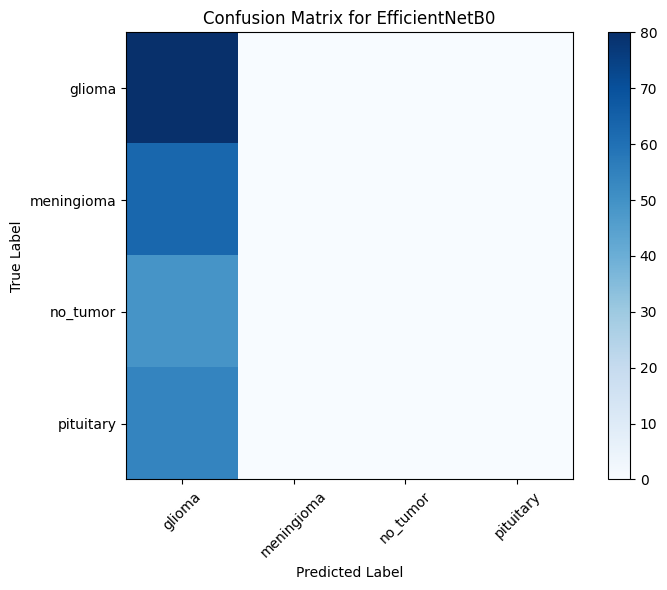


Plotting Training History...


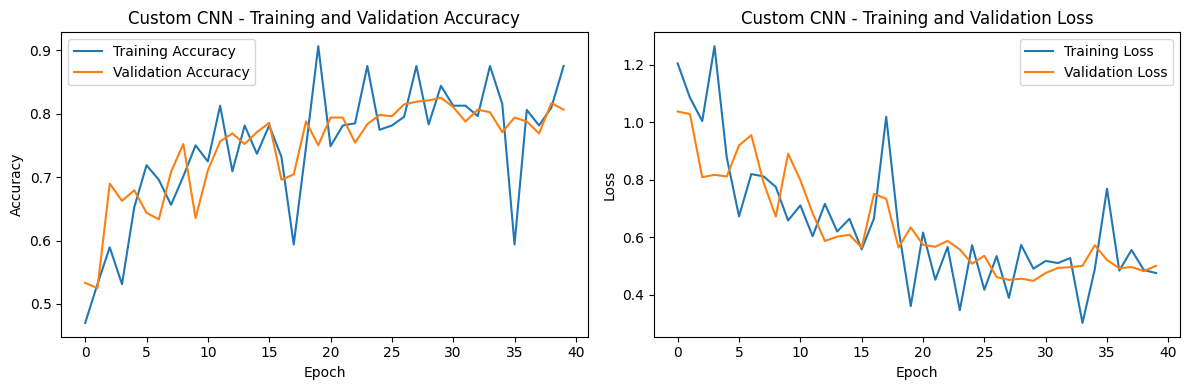

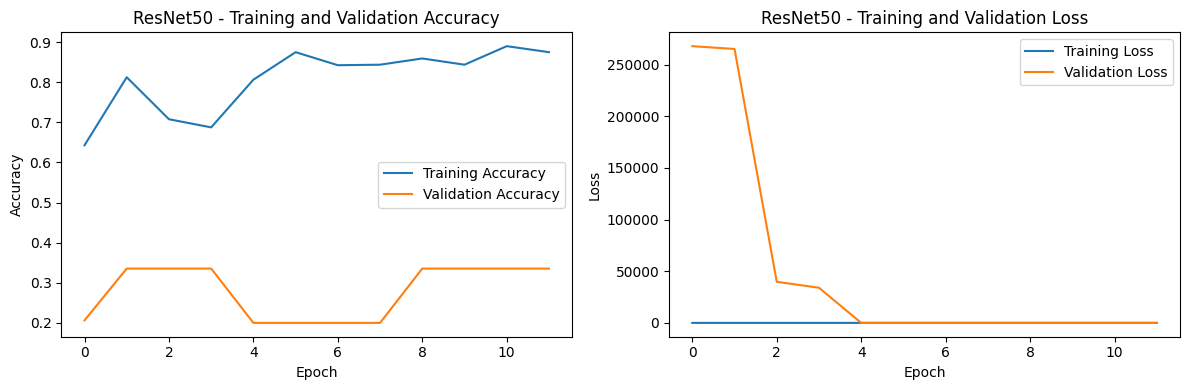

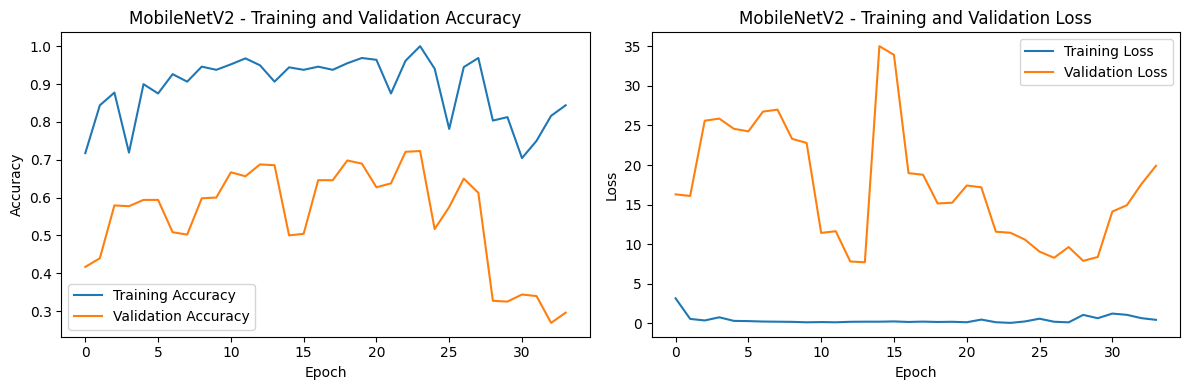

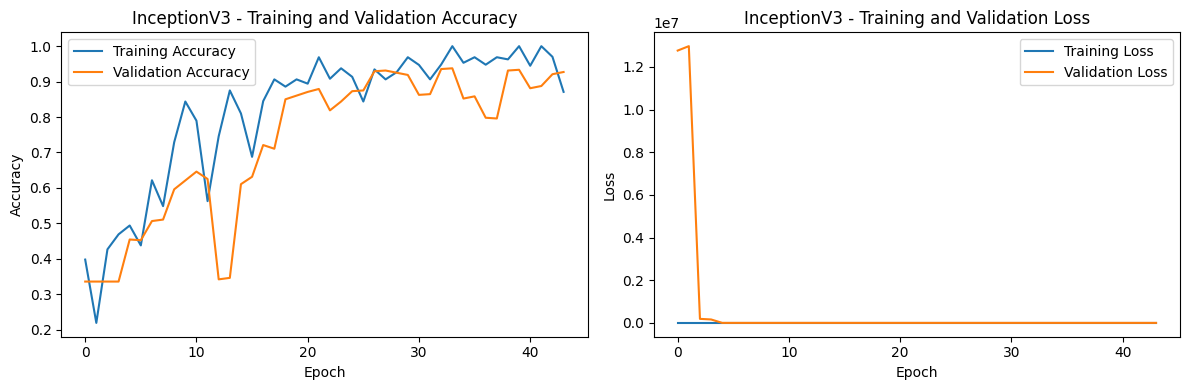

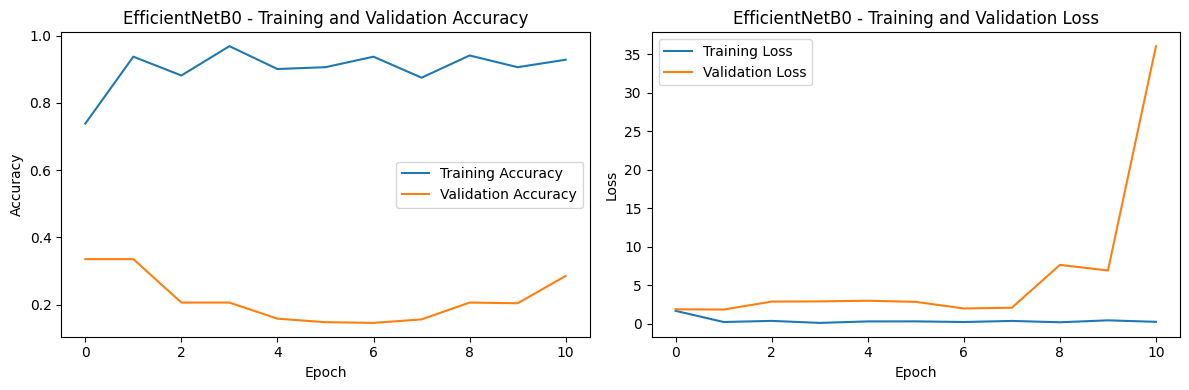

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Function to evaluate a model
def evaluate_model(model, test_data, model_name):
    print(f"Evaluating {model_name}...")
    # Get predictions
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true labels
    # Resetting the test_data generator is important to ensure the order of predictions matches the order of labels
    test_data.reset()
    y_true = test_data.classes

    # Get class labels
    class_labels = list(test_data.class_indices.keys())

    # Classification Report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_true, y_pred_classes, target_names=class_labels))

    # Confusion Matrix
    print(f"\nConfusion Matrix for {model_name}:\n")
    cm = confusion_matrix(y_true, y_pred_classes)
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.colorbar()
    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=45)
    plt.yticks(tick_marks, class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Evaluate each model
evaluate_model(model, test_data, "Custom CNN")
evaluate_model(resnet_model, test_data, "ResNet50")
evaluate_model(mobilenet_model, test_data, "MobileNetV2")
evaluate_model(inception_model, test_data, "InceptionV3")
evaluate_model(efficientnet_model, test_data, "EfficientNetB0")

# Function to plot training history
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot training history for each model
print("\nPlotting Training History...")
plot_training_history(history_custom_cnn, "Custom CNN")
plot_training_history(history_resnet, "ResNet50")
plot_training_history(history_mobilenet, "MobileNetV2")
plot_training_history(history_inception, "InceptionV3")
plot_training_history(history_efficientnet, "EfficientNetB0")

## Model Comparison

### Subtask:
Compare results of custom CNN vs pretrained models. Identify the most accurate, efficient, and reliable model for deployment.

**Reasoning**:
Based on the evaluation metrics and training history plots from the previous step, compare the performance of the custom CNN and transfer learning models. Analyze accuracy, precision, recall, F1-score, and observe the training and validation curves to identify the model that demonstrates the best balance of performance and generalization on the validation data. Consider factors like overfitting (large gap between training and validation metrics) and stability during training.